#### Supervised Learning Algorithms - Linear Regression: Assume the dataset to Create a Simple Linear Regression model. Predict the scores on the test data and output RMSE and R Squared Score. Include appropriate code snippets to visualize the model. Interpret the result.

In [139]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [140]:
df = pd.read_csv("advertising.csv")
df.head()

df.drop(['Unnamed: 0'], inplace=True, axis='columns')
df.rename(columns={"TV": "television"}, inplace=True)
df.head()

,television,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [141]:
X = df[["television", "radio", "newspaper"]]
y = df["sales"]

In [142]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.25)

In [143]:
def plot_test_pred_data(X_test, y_pred, y_test, advert_type: str, sc_color: str, pl_color: str):
    plt.figure(figsize=(8, 6))
    plt.plot(X_test[advert_type], y_pred, color=f"{pl_color}", linestyle="--", label="Regression Line")
    plt.scatter(X_test[advert_type], y_test, color=f"{sc_color}", label=f"{advert_type.capitalize()} Test Data", alpha=0.7)

    plt.xlabel(f"Investment into {advert_type.capitalize()} Advertisements")
    plt.ylabel("Sales")

    plt.grid()
    plt.legend()
    plt.show()

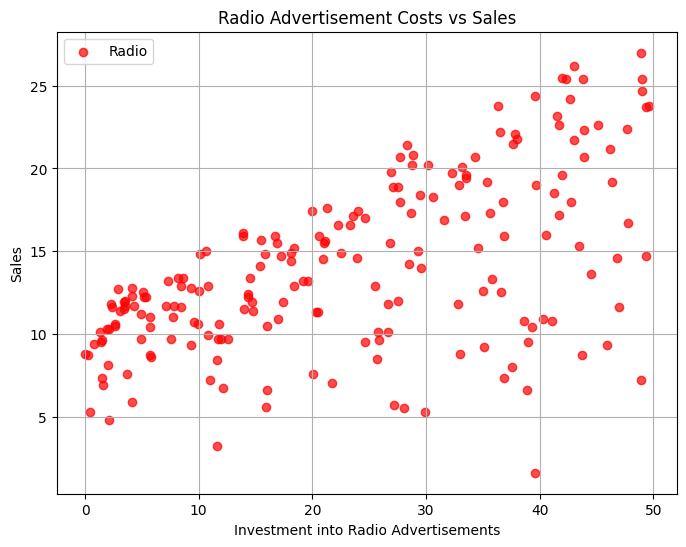

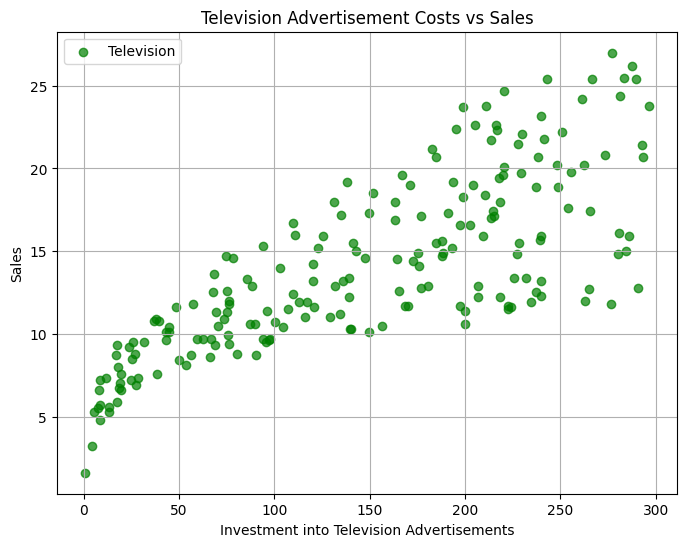

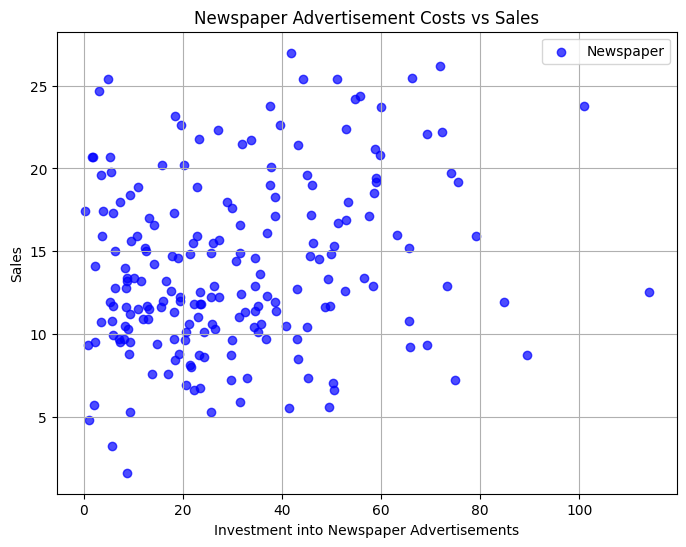

In [144]:
def plot_adv_data(advert_type: str, color: str):
    plt.figure(figsize=(8, 6))
    plt.scatter(X[advert_type], y, color=f"{color}", alpha=0.7, label=f"{advert_type.capitalize()}")
    plt.legend()
    plt.grid()
    plt.title(f"{advert_type.capitalize()} Advertisement Costs vs Sales")
    plt.xlabel(f"Investment into {advert_type.capitalize()} Advertisements")
    plt.ylabel("Sales")

plot_adv_data("radio", "red")
plot_adv_data("television", "green")
plot_adv_data("newspaper", "blue")

In [145]:
r_model = LinearRegression()
r_model.fit(X_train[["radio"]], y_train)

y_pred = r_model.predict(X_test[["radio"]])

coefficient = r_model.coef_[0]
intercept = r_model.intercept_

print(f"Coefficient: {coefficient}")
print(f"Intercept: {intercept}")

print("--Evaluation--")
print(f"RMSE: {np.sqrt(mean_squared_error(y_pred, y_test))}")
print(f"r^2 score: {r2_score(y_pred, y_test)}")

Coefficient: 0.20404289801490136
Intercept: 9.510202677711192
--Evaluation--
RMSE: 4.451787744912085
r^2 score: -1.2192121971676522


- Based on the coefficient - The radio model has the relatively the strongest impact, suggesting that the sales figures are most affected by the expenditure in Radio advertisements.
- Based on the RMSE, the model is off by 4.45 units on average. Since sales is in the range of 0 to 25, that is a big chunk of error. Therefore the model is not good at predictions.
- A good model has an r^2 closer to 1. However, the radio model, has a negative r^2, which is really bad. Therefore the regression curve is not a good fit for the data.

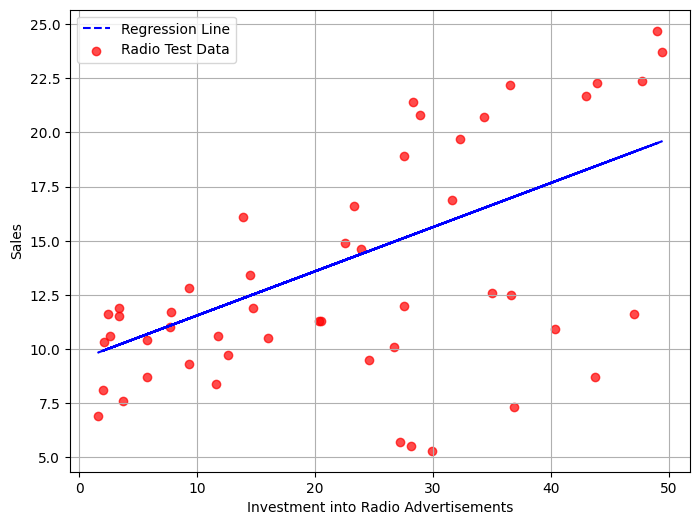

In [146]:
plot_test_pred_data(X_test, y_pred, y_test, advert_type="radio", sc_color="red", pl_color="blue")

In [147]:
t_model = LinearRegression()
t_model.fit(X_train[["television"]], y_train)

y_pred = t_model.predict(X_test[["television"]])

coefficient = t_model.coef_[0]
intercept = t_model.intercept_

print(f"Coefficient: {coefficient}")
print(f"Intercept: {intercept}")

print("--Evaluation--")
print(f"RMSE: {np.sqrt(mean_squared_error(y_pred, y_test))}")
print(f"r^2 score: {r2_score(y_pred, y_test)}")

Coefficient: 0.046894455732824275
Intercept: 7.131784506685331
--Evaluation--
RMSE: 3.0297357261648736
r^2 score: 0.43100480902944716


- Based on the coefficient - The television model has a relatively weak impact, suggesting that the sales figures are not very affected by the television advertisement figures.
- Based on the RMSE, the model is off by 3.02 units on average. Since sales is in the range of 0 to 25, that is an acceptable range of error, but still not very good.
- A good model has an r^2 closer to 1. The television model has an r^2 relatively closer to 1, and is hence an acceptable fit over the data.

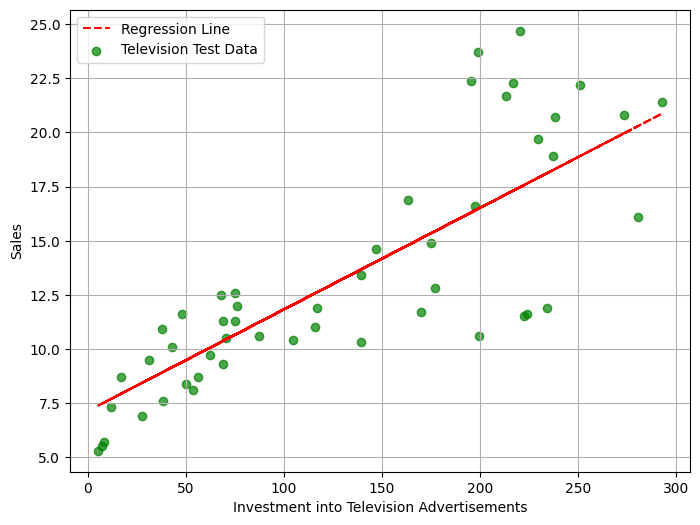

In [148]:
plot_test_pred_data(X_test, y_pred, y_test, advert_type="television", sc_color="green", pl_color="red")

In [149]:
n_model = LinearRegression()
n_model.fit(X_train[["newspaper"]], y_train)

y_pred = n_model.predict(X_test[["newspaper"]])

coefficient = n_model.coef_[0]
intercept = n_model.intercept_

print(f"Coefficient: {coefficient}")
print(f"Intercept: {intercept}")

print("--Evaluation--")
print(f"RMSE: {np.sqrt(mean_squared_error(y_pred, y_test))}")
print(f"r^2 score: {r2_score(y_pred, y_test)}")

Coefficient: 0.05812370896323025
Intercept: 12.534334739064601
--Evaluation--
RMSE: 5.199566461555719
r^2 score: -12.186755231264844


- Based on the coefficient - The television model has a relatively sparse impact, suggesting that the sales figures are not very affected by the newspaper advertisement figures.
- Based on the RMSE, the model is off by 5.19 units on average. Since sales is in the range of 0 to 25, that is a high error figure, and we may conclude that the model is not good for predictive endeavours.
- A good model has an r^2 closer to 1. The television model has a very negative r^2 score, which suggests that it is a very bad fit on the data.

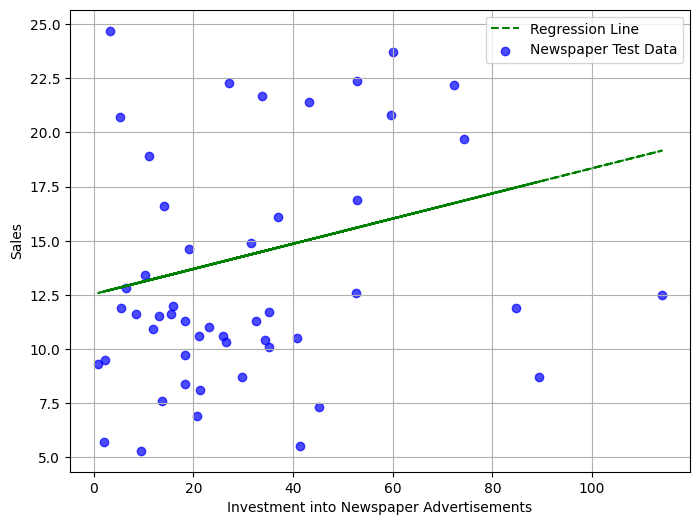

In [150]:
plot_test_pred_data(X_test, y_pred, y_test, advert_type="newspaper", sc_color="blue", pl_color="green")